# Session 3: Large Language Models

Large language models (LLMs) are neural networks trained to predict the next token in a sequence. That deceptively simple objective produces surprisingly broad capabilities: commonsense reasoning, question answering, summarization, code generation, and instruction following. Modern LLM workflows usually combine three stages: loading a pretrained model, measuring its performance on a targeted task, and then finetuning it so that the model adapts to the specific patterns we need.

In this session we build a compact end-to-end workflow around **Qwen 2.5 3B Instruct**, a capable open-weight instruction-tuned model:

1. **Explore tokenization** — understand how text becomes tokens and why it matters.
2. **Understand autoregressive generation** — see how decoding strategy changes model output.
3. **Frame ARC-Challenge as an instruction task** — a challenging multiple-choice science benchmark that tests reasoning and applied knowledge.
4. **Evaluate the pretrained model** zero-shot and measure its baseline accuracy.
5. **Finetune with LoRA** on a small subset and compare accuracy before and after.
6. **Call the OpenAI API** for inference with a hosted frontier model.

By the end you will have seen the full LLM lifecycle: tokenization → autoregressive generation → task framing → parameter-efficient finetuning → hosted API inference.

## 0. Setup

We use **Transformers** for model loading, **datasets** for data access, **PEFT** for parameter-efficient finetuning, and **Matplotlib** for visualization. The final section uses the OpenAI API.

In [1]:
! pip install -q transformers datasets accelerate peft trl openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 16.5 MB/s eta 0:00:00


In [ ]:
%matplotlib inline


import os
import torch
import random
from pathlib import Path
from tqdm.auto import tqdm
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, default_data_collator

IN_COLAB = 'google.colab' in str(get_ipython())
RUNTIME_ROOT = Path('/content' if IN_COLAB else '.').resolve()
HF_CACHE_ROOT = RUNTIME_ROOT / 'hf_cache'
HF_HUB_CACHE = HF_CACHE_ROOT / 'hub'
HF_DATASETS_CACHE = HF_CACHE_ROOT / 'datasets'
OUTPUT_ROOT = RUNTIME_ROOT / 'artifacts'

HF_HUB_CACHE.mkdir(parents=True, exist_ok=True)
HF_DATASETS_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_CACHE_ROOT)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(HF_HUB_CACHE)
os.environ['HF_HUB_CACHE'] = str(HF_HUB_CACHE)
os.environ['TRANSFORMERS_CACHE'] = str(HF_HUB_CACHE)
os.environ['HF_DATASETS_CACHE'] = str(HF_DATASETS_CACHE)


SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type != 'cuda':
    print('WARNING: A CUDA GPU is strongly recommended.')
print(f'Runtime root : {RUNTIME_ROOT}')
print(f'HF cache     : {HF_CACHE_ROOT}')

Using device: cuda
Runtime root : /content
HF cache     : /content/hf_cache


---

## 1. Load the Model and Tokenizer

We work with **Qwen2.5-3B-Instruct**, a 3-billion-parameter instruction-tuned model from Alibaba's Qwen team. At this size it shows strong commonsense and science reasoning while still being practical to finetune.

We load the model in `float16` on the GPU and define a helper that applies the model's built-in **chat template** — the function that converts a list of `{"role": ..., "content": ...}` messages into the exact token string the model was trained to expect. Different models use different templates, which is why using `apply_chat_template` is always safer than hand-crafting delimiters.

In [3]:
MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

torch_dtype = torch.float16 if device.type == 'cuda' else torch.float32
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype)
base_model.to(device)
base_model.eval()

SYSTEM_PROMPT = (
    'You are a science reasoning assistant. '
    'Answer multiple-choice questions with exactly one letter: A, B, C, or D.'
)

def render_messages(messages, add_generation_prompt=False):
    if tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )
    prompt = ''
    for msg in messages:
        prompt += f"{msg['role'].upper()}: {msg['content']}\n"
    if add_generation_prompt:
        prompt += 'ASSISTANT: '
    return prompt

total_params = sum(p.numel() for p in base_model.parameters())
print(f'Model        : {MODEL_NAME}')
print(f'Parameters   : {total_params / 1e9:.2f}B')
print(f'Vocab size   : {tokenizer.vocab_size:,}')
print(f'dtype        : {torch_dtype}')

# Preview what a chat-templated prompt looks like
preview = render_messages(
    [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': 'What gas do plants absorb?\nA) Oxygen\nB) Carbon dioxide\nC) Nitrogen\nD) Hydrogen\nAnswer with exactly one letter.'},
    ],
    add_generation_prompt=True,
)
print('\nSample chat-templated prompt:\n')
print(preview[:600])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model        : Qwen/Qwen2.5-3B-Instruct
Parameters   : 3.09B
Vocab size   : 151,643
dtype        : torch.float16

Sample chat-templated prompt:

<|im_start|>system
You are a science reasoning assistant. Answer multiple-choice questions with exactly one letter: A, B, C, or D.<|im_end|>
<|im_start|>user
What gas do plants absorb?
A) Oxygen
B) Carbon dioxide
C) Nitrogen
D) Hydrogen
Answer with exactly one letter.<|im_end|>
<|im_start|>assistant



### 1.1 Tokenization Explorer

Before evaluating or finetuning a model it is worth understanding what a *token* actually is. LLMs do not read characters or words — they read **tokens**: units produced by a **Byte-Pair Encoding (BPE)** algorithm that compresses frequent character sequences into single symbols. Qwen 2.5 has a vocabulary of ~150 K tokens.

A few things worth noticing in the cell below:

- Common English words are usually a single token; rare or technical words are split into subwords.
- **Numbers are tokenized digit-by-digit or in small groups** — a key reason why arithmetic is hard for LLMs without special training.
- The same content written differently uses different token counts, which affects both cost (API pricing) and performance.
- Special tokens like `<|im_start|>` and `<|im_end|>` (Qwen's "Instruction Markup") delimit role boundaries in the chat template and are never seen during normal text generation.

In [ ]:
examples = [
    "The cat sat on the mat.",
    "Photosynthesis converts carbon dioxide and water into glucose.",
    "2025 + 1337 = 3362",
    "Supercalifragilisticexpialidocious",
    "I love deep learning!",
]

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"Special tokens  : {tokenizer.all_special_tokens[:8]} …")
print()

for text in examples:
    ids    = tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode([i]) for i in ids]
    print(f"Text   : {text}")
    print(f"Tokens : {tokens}")
    print(f"IDs    : {ids}")
    print(f"Count  : {len(ids)} tokens")
    print()

# Show how the chat template adds special structure tokens
demo_messages = [
    {'role': 'system', 'content': SYSTEM_PROMPT},
    {'role': 'user',   'content': 'What is the boiling point of water?'},
]
templated     = render_messages(demo_messages, add_generation_prompt=True)
templated_ids = tokenizer.encode(templated)
print("─" * 60)
print("Chat-templated prompt (rendered):\n")
print(templated)
print(f"Total tokens after templating: {len(templated_ids)}")

Vocabulary size : 151,643
Special tokens  : ['<|im_end|>', '<|endoftext|>', '<|im_start|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>'] …

Text   : The cat sat on the mat.
Tokens : ['The', ' cat', ' sat', ' on', ' the', ' mat', '.']
IDs    : [785, 8251, 7578, 389, 279, 5517, 13]
Count  : 7 tokens

Text   : Photosynthesis converts carbon dioxide and water into glucose.
Tokens : ['Photos', 'ynthesis', ' converts', ' carbon', ' dioxide', ' and', ' water', ' into', ' glucose', '.']
IDs    : [31772, 73667, 32722, 12499, 39489, 323, 3015, 1119, 33223, 13]
Count  : 10 tokens

Text   : 2025 + 1337 = 3362
Tokens : ['2', '0', '2', '5', ' +', ' ', '1', '3', '3', '7', ' =', ' ', '3', '3', '6', '2']
IDs    : [17, 15, 17, 20, 488, 220, 16, 18, 18, 22, 284, 220, 18, 18, 21, 17]
Count  : 16 tokens

Text   : Supercalifragilisticexpialidocious
Tokens : ['Sup', 'erc', 'al', 'if', 'rag', 'il', 'istic', 'exp', 'ial', 'id', 'ocious']
IDs    : [10048, 2962,

### 1.2 Autoregressive Generation and Decoding Strategies

At inference time an LLM generates text **one token at a time**. At each step it produces a probability distribution over its entire vocabulary (~150 K tokens for Qwen 2.5) and draws the next token from that distribution. The **decoding strategy** controls how that draw happens:

| Strategy | Behavior | When to use |
|---|---|---|
| **Greedy** | Always pick the highest-probability token. Fully deterministic. | Structured outputs, classification |
| **Temperature** | Divide logits by *T* before softmax. *T* < 1 → more peaked (conservative); *T* > 1 → flatter (creative/noisy). | Tuning diversity vs. coherence |
| **Top-p (nucleus)** | Sample from the smallest set of tokens whose cumulative probability ≥ *p*. | Good general-purpose default |

The cell below runs the same science-teacher prompt through all four strategies. Notice how the text changes from deterministic and safe to varied and sometimes surprising.

In [5]:
gen_prompt_text = render_messages(
    [
        {'role': 'system', 'content': 'You are a helpful and curious science teacher.'},
        {'role': 'user',   'content': 'Briefly explain why the sky is blue in 2-3 sentences.'},
    ],
    add_generation_prompt=True,
)
gen_inputs = tokenizer(gen_prompt_text, return_tensors='pt').to(device)
prompt_len = gen_inputs['input_ids'].shape[1]

strategies = {
    'Greedy (deterministic)':   dict(do_sample=False,                            max_new_tokens=80),
    'Temperature 0.3 (focused)':dict(do_sample=True,  temperature=0.3,           max_new_tokens=80),
    'Temperature 1.2 (creative)':dict(do_sample=True,  temperature=1.2,          max_new_tokens=80),
    'Top-p 0.9 (nucleus)':      dict(do_sample=True,  top_p=0.9, temperature=1.0, max_new_tokens=80),
}

print('=' * 70)
with torch.no_grad():
    for name, kwargs in strategies.items():
        out = base_model.generate(
            **gen_inputs,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs,
        )
        text = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
        print(f'\n[{name}]')
        print(text)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



[Greedy (deterministic)]
The sky appears blue because of a phenomenon called Rayleigh scattering. Sunlight contains all colors of the spectrum, and when sunlight enters Earth's atmosphere, it collides with air molecules. Blue light is scattered more than other colors due to its shorter wavelength, causing us to see a predominantly blue sky during the day.

[Temperature 0.3 (focused)]
The sky appears blue because of a phenomenon called Rayleigh scattering. Sunlight enters Earth's atmosphere and collides with molecules and small particles in the air. Shorter wavelength light, like blue, is scattered more than longer wavelength light like red due to its smaller size relative to the wavelengths. This is why we see the sky predominantly blue during the day, with scattered red hues at sunrise and sunset when

[Temperature 1.2 (creative)]
The sky appears blue because sunlight, which is made up of many colors, is scattered by the tiny particles in Earth's atmosphere. Blue light is scattered m

---

## 2. Load and Inspect ARC-Challenge

The **AI2 Reasoning Challenge (ARC-Challenge)** is a multiple-choice benchmark of genuine grade-school science questions that require multi-step reasoning or applied knowledge. Each example has 3–4 answer choices and a single correct answer.

ARC-Challenge comes with 1119 training, 299 validation, and 1172 test examples — compact enough for fast finetuning experiments.

In [6]:
raw_dataset = load_dataset('allenai/ai2_arc', 'ARC-Challenge')

def normalize_arc(example):
    """Normalize ARC schema to a consistent format used throughout the notebook."""
    return {
        'question':  example['question'],
        'labels':    example['choices']['label'],
        'texts':     example['choices']['text'],
        'answerKey': example['answerKey'],
    }

_cols = raw_dataset['train'].column_names

TRAIN_SIZE = 512

train_dataset = (
    raw_dataset['train']
    .shuffle(seed=SEED)
    .select(range(TRAIN_SIZE))
    .map(normalize_arc, remove_columns=_cols)
)
eval_dataset = raw_dataset['validation'].map(normalize_arc, remove_columns=_cols)

def format_choices(example):
    return '\n'.join(f'{l}) {t}' for l, t in zip(example['labels'], example['texts']))

def build_user_prompt(example):
    return (
        f"Question: {example['question']}\n"
        f"{format_choices(example)}\n"
        'Answer with exactly one letter.'
    )

print(f'Train: {len(train_dataset)} examples  |  Eval: {len(eval_dataset)} examples')
print()
for i in range(3):
    ex = eval_dataset[i]
    print(f"Example {i + 1}")
    print(f"Q: {ex['question']}")
    print(format_choices(ex))
    print(f"Answer: {ex['answerKey']}")
    print()

README.md: 0.00B [00:00, ?B/s]

ARC-Challenge/train-00000-of-00001.parqu(…):   0%|          | 0.00/190k [00:00<?, ?B/s]

ARC-Challenge/test-00000-of-00001.parque(…):   0%|          | 0.00/204k [00:00<?, ?B/s]

ARC-Challenge/validation-00000-of-00001.(…):   0%|          | 0.00/55.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1119 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Map:   0%|          | 0/299 [00:00<?, ? examples/s]

Train: 512 examples  |  Eval: 299 examples

Example 1
Q: Juan and LaKeisha roll a few objects down a ramp. They want to see which object rolls the farthest. What should they do so they can repeat their investigation?
A) Put the objects in groups.
B) Change the height of the ramp.
C) Choose different objects to roll.
D) Record the details of the investigation.
Answer: D

Example 2
Q: High-pressure systems stop air from rising into the colder regions of the atmosphere where water can condense. What will most likely result if a high-pressure system remains in an area for a long period of time?
A) fog
B) rain
C) drought
D) tornado
Answer: C

Example 3
Q: Students visited the Morris W. Offit telescope located at the Maryland Space Grant Observatory in Baltimore. They learned about the stars, planets, and moon. The students recorded the information below. • Star patterns stay the same, but their locations in the sky seem to change. • The sun, planets, and moon appear to move in the sky. • Pr

---

Before any prompting or training, we establish a **zero-shot baseline** on the ARC-Challenge validation set. This single number is our reference point for comparison with the finetuned model.

We use **log-probability scoring** rather than open-ended generation: for each candidate letter (A–D) we append it to the prompt and record the model's log-probability for that token. The letter with the highest score is the prediction. This is more stable and reproducible than sampling, and the same function is reused for the finetuned model so the comparison is completely fair.

Qwen 2.5 3B is a strong model but ARC-Challenge requires multi-step reasoning — expect a zero-shot accuracy somewhere in the **80–90 %** range, leaving room for both prompting and finetuning to push the number higher.

In [ ]:
@torch.no_grad()
def score_candidates(model, example):
    """Score each answer letter via log-probability and return the prediction."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': build_user_prompt(example)},
    ]
    prompt_text   = render_messages(messages, add_generation_prompt=True)
    prompt_inputs = tokenizer(prompt_text, return_tensors='pt').to(device)
    prompt_len    = prompt_inputs['input_ids'].shape[1]

    scores = {}
    for label in example['labels']:
        label_ids    = tokenizer.encode(label, add_special_tokens=False)
        label_tensor = torch.tensor([label_ids], device=device)
        input_ids    = torch.cat([prompt_inputs['input_ids'], label_tensor], dim=1)
        attn_mask    = torch.cat(
            [prompt_inputs['attention_mask'], torch.ones_like(label_tensor)], dim=1
        )
        logits = model(input_ids=input_ids, attention_mask=attn_mask).logits[0]

        total_logprob = 0.0
        for idx, token_id in enumerate(label_ids):
            pos = prompt_len + idx
            total_logprob += torch.log_softmax(logits[pos - 1], dim=-1)[token_id].item()
        scores[label] = total_logprob

    prediction = max(scores, key=scores.get)
    return prediction, scores


def evaluate_model(model, dataset, limit=None):
    """Evaluate model accuracy on dataset using log-prob scoring."""
    subset = dataset.select(range(min(limit, len(dataset)))) if limit else dataset
    rows = []
    for ex in tqdm(subset):
        gold = ex['answerKey']
        pred, scores = score_candidates(model, ex)
        rows.append({
            'gold': gold, 'pred': pred, 'scores': scores,
            'correct': pred == gold,
            'question': ex['question'], 'choices': format_choices(ex),
        })
    accuracy = sum(r['correct'] for r in rows) / len(rows)
    return accuracy, rows

In [8]:
# ── Zero-shot baseline ────────────────────────────────────────────────────────
baseline_accuracy, baseline_rows = evaluate_model(base_model, eval_dataset)
n_correct = int(baseline_accuracy * len(baseline_rows))
print(f'Zero-shot accuracy: {baseline_accuracy:.3f}  ({n_correct}/{len(baseline_rows)} correct)')
print()

# A few sample predictions
for row in baseline_rows[:4]:
    mark = '✓' if row['correct'] else '✗'
    scores_str = '  '.join(f'{k}:{v:.1f}' for k, v in row['scores'].items())
    print(f"{mark} gold={row['gold']} pred={row['pred']}  [{scores_str}]")
    print(f"  {row['question'][:90]}")
    print()

  0%|          | 0/299 [00:00<?, ?it/s]

Zero-shot accuracy: 0.839  (251/299 correct)

✓ gold=D pred=D  [A:-20.7  B:-16.7  C:-22.8  D:0.0]
  Juan and LaKeisha roll a few objects down a ramp. They want to see which object rolls the 

✓ gold=C pred=C  [A:-20.7  B:-20.1  C:0.0  D:-18.6]
  High-pressure systems stop air from rising into the colder regions of the atmosphere where

✓ gold=D pred=D  [A:-19.4  B:-20.8  C:-23.1  D:0.0]
  Students visited the Morris W. Offit telescope located at the Maryland Space Grant Observa

✓ gold=A pred=A  [A:0.0  B:-21.2  C:-24.0  D:-23.5]
  Which topic area would be the best to research to find ways of reducing environmental prob



## 4. Finetune with LoRA

Zero-shot evaluation tells us what the pretrained model already knows. **LoRA** (Low-Rank Adaptation) goes further by adapting a small fraction of model parameters to the task distribution — updating the model's weights to match the specific question style and answer format of ARC-Challenge.

**How LoRA works:** for a weight matrix **W**, we add **ΔW = A × B** where **A** and **B** have rank *r* ≪ min(rows, cols). Only **A** and **B** are trained, representing **< 0.5 %** of total parameters. At inference time the adapter can be merged back into **W** at zero extra cost.

**Training target:** we train the model to generate the correct answer letter (`"A"`, `"B"`, `"C"`, or `"D"`), which is exactly what the system prompt instructs: *"Answer with exactly one letter."*

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total parameters : 3093.3M
Trainable (LoRA) : 7372.8K  (0.24%)


Step,Training Loss
5,0.584051
10,0.513122
15,0.137434
20,0.232423
25,0.158303
30,0.173180
35,0.127774
40,0.049168
45,0.086177
50,0.068345


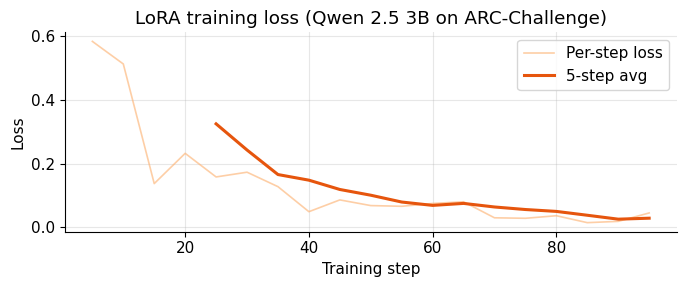

In [10]:
import gc

MAX_LENGTH = 256

def build_training_text(example):
    """Supervised example: the target is the bare letter (A/B/C/D).
    Matches the system-prompt instruction ('answer with exactly one letter')
    and the log-prob scoring in score_candidates, ensuring train/eval consistency."""
    messages = [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': build_user_prompt(example)},
        {'role': 'assistant', 'content': example['answerKey']},   # bare letter
    ]
    return render_messages(messages, add_generation_prompt=False)

def tokenize_supervised_example(example):
    prompt_text = render_messages(
        [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': build_user_prompt(example)},
        ],
        add_generation_prompt=True,
    )
    full_text  = build_training_text(example)
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    tokenized  = tokenizer(full_text, truncation=True, max_length=MAX_LENGTH, padding='max_length')
    labels     = tokenized['input_ids'].copy()
    prompt_length = min(len(prompt_ids), MAX_LENGTH)
    labels[:prompt_length] = [-100] * prompt_length
    labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]
    tokenized['labels'] = labels
    return tokenized

train_tokenized = train_dataset.map(tokenize_supervised_example, remove_columns=train_dataset.column_names)

# Free base model GPU memory before loading the LoRA copy
try:
    del base_model
except NameError:
    pass
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
)

finetuned_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype)
finetuned_model.to(device)
finetuned_model.config.use_cache = False
finetuned_model = get_peft_model(finetuned_model, lora_config)
finetuned_model.enable_input_require_grads()

total_params     = sum(p.numel() for p in finetuned_model.parameters())
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)
print(f'Total parameters : {total_params / 1e6:.1f}M')
print(f'Trainable (LoRA) : {trainable_params / 1e3:.1f}K  ({100 * trainable_params / total_params:.2f}%)')

use_bf16 = device.type == 'cuda' and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir=str(OUTPUT_ROOT / 'qwen25_lora_arc'),
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch = 16
    gradient_checkpointing=True,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    logging_steps=5,
    save_strategy='no',
    report_to='none',
    bf16=use_bf16,
    fp16=(not use_bf16 and device.type == 'cuda'),
    remove_unused_columns=False,
)

trainer = Trainer(
    model=finetuned_model,
    args=training_args,
    train_dataset=train_tokenized,
    data_collator=default_data_collator,
)

trainer.train()

# Switch to eval mode and restore KV-cache for fast inference
finetuned_model.eval()
finetuned_model.config.use_cache = True

log_history = [e for e in trainer.state.log_history if 'loss' in e]
if log_history:
    steps  = [e['step'] for e in log_history]
    losses = [e['loss'] for e in log_history]
    import numpy as np
    window = min(5, len(losses))
    smooth = np.convolve(losses, np.ones(window) / window, mode='valid')
    smooth_steps = steps[window - 1:]

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(steps, losses, color='#fdae6b', linewidth=1.2, alpha=0.6, label='Per-step loss')
    ax.plot(smooth_steps, smooth, color='#e6550d', linewidth=2.2, label=f'{window}-step avg')
    ax.set_xlabel('Training step')
    ax.set_ylabel('Loss')
    ax.set_title('LoRA training loss (Qwen 2.5 3B on ARC-Challenge)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Evaluate, Compare, and Analyze

We run the same log-probability evaluation on the finetuned model against the identical `eval_dataset` and compare accuracy before and after finetuning.

In [ ]:
finetuned_accuracy, finetuned_rows = evaluate_model(finetuned_model, eval_dataset)

Zero-shot pretrained  : 0.839
LoRA finetuned        : 0.863
Δ (0-shot → LoRA)     : +0.023


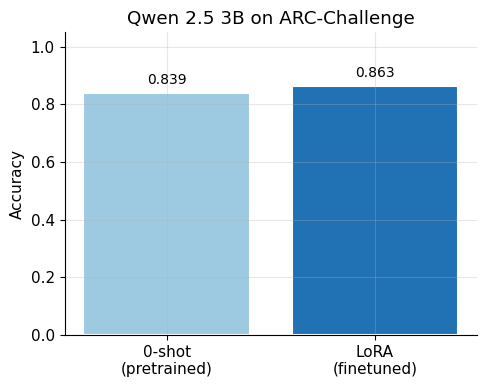

In [24]:
print(f'Zero-shot pretrained  : {baseline_accuracy:.3f}')
print(f'LoRA finetuned        : {finetuned_accuracy:.3f}')
print(f'Δ (0-shot → LoRA)     : {finetuned_accuracy - baseline_accuracy:+.3f}')

fig, ax = plt.subplots(figsize=(5, 4))

method_labels = ['0-shot\n(pretrained)', 'LoRA\n(finetuned)']
method_accs   = [baseline_accuracy, finetuned_accuracy]
colors        = ['#9ecae1', '#2171b5']
bars = ax.bar(method_labels, method_accs, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Qwen 2.5 3B on ARC-Challenge')
for bar, v in zip(bars, method_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
fixed   = [(b, a) for b, a in zip(baseline_rows, finetuned_rows) if not b['correct'] and a['correct']]
broken  = [(b, a) for b, a in zip(baseline_rows, finetuned_rows) if b['correct'] and not a['correct']]
persist = [(b, a) for b, a in zip(baseline_rows, finetuned_rows) if not b['correct'] and not a['correct']]

print(f'Fixed by finetuning  : {len(fixed):3d}  (wrong → correct)')
print(f'Broken by finetuning : {len(broken):3d}  (correct → wrong)')
print(f'Still wrong          : {len(persist):3d}')
print(f'Net change           : {len(fixed) - len(broken):+d}')

def show_examples(pairs, title, n=1):
    print(f'\n{"─" * 70}')
    print(title)
    print('─' * 70)
    for before, after in pairs[:n]:
        print(f"Q: {before['question']}")
        print(before['choices'])
        print(f"Gold: {before['gold']}  |  Before: {before['pred']}  |  After: {after['pred']}")
        print()

show_examples(fixed,   'FIXED BY FINETUNING')
show_examples(broken,  'BROKEN BY FINETUNING  (regression)')
show_examples(persist, 'STILL WRONG  (hard cases)')

Fixed by finetuning  :  15  (wrong → correct)
Broken by finetuning :   8  (correct → wrong)
Still wrong          :  33
Net change           : +7

──────────────────────────────────────────────────────────────────────
FIXED BY FINETUNING
──────────────────────────────────────────────────────────────────────
Q: Janette conducts an investigation to see which foods make her feel more fatigued. She eats one of four different foods each day at the same time for four days and then records how she feels. She asks her friend Carmen to do the same investigation to see if she gets similar results. Which would make the investigation most difficult to replicate?
A) measuring the amount of fatigue
B) making sure the same foods are eaten
C) recording observations in the same chart
D) making sure the foods are at the same temperature
Gold: A  |  Before: B  |  After: A


──────────────────────────────────────────────────────────────────────
BROKEN BY FINETUNING  (regression)
───────────────────────────

## 6. Call the OpenAI API and Inspect a Sample Response

Open-source models and hosted APIs fit different use cases. Finetuning a local model gives you direct control over training and evaluation, while a hosted API gives fast access to a stronger general-purpose model without managing checkpoints yourself.

In [22]:
import os

from openai import OpenAI

api_key = "sk-proj-abcd1234"

client = OpenAI(api_key=api_key)
response = client.responses.create(
    model='gpt-5-mini',
    input='In a couple of sentences, explain why finetuning can improve task-specific performance for a small language model.',
)

print(response.output_text)

Finetuning updates a pretrained model’s weights on task-specific examples so it learns the particular input–output patterns, formats, and biases the task requires—things generic pretraining may not have emphasized. For a small model, finetuning concentrates its limited capacity on those relevant features and decision boundaries, often improving accuracy, calibration, and robustness on the target task.


### 6.1 Structured Outputs

In many applications, free-form text is not enough. You may want a model to return a predictable object such as a label, a confidence score, and a short explanation. Structured outputs help with that by constraining the response to a schema. The example below defines a small Pydantic class and asks the model to return data that matches it. It is especially useful when the output will be consumed by another program instead of a human reader.

In [23]:
from typing import Literal
from pydantic import BaseModel


class SentimentAnalysis(BaseModel):
    label: Literal['positive', 'negative']
    confidence: float
    summary: str


structured_response = client.responses.parse(
    model='gpt-5-mini',
    input=[
        {
            'role': 'system',
            'content': 'You are a sentiment analysis assistant. Return the answer using the requested structured format.',
        },
        {
            'role': 'user',
            'content': 'Analyze this review: "The movie starts slowly, but the performances and ending are excellent."',
        },
    ],
    text_format=SentimentAnalysis,
)

parsed = structured_response.output_parsed
print(parsed)
print()
print(f'label      : {parsed.label}')
print(f'confidence : {parsed.confidence:.2f}')
print(f'summary    : {parsed.summary}')

label='positive' confidence=0.87 summary='Mixed review noting a slow start, but praises the performances and ending; overall sentiment is positive.'

label      : positive
confidence : 0.87
summary    : Mixed review noting a slow start, but praises the performances and ending; overall sentiment is positive.
